In [1]:
import pandas as pd

df = pd.read_csv("../data/spam_Emails_data.csv")

print(df.shape)
df.head()

(193852, 2)


,label,text
0,Spam,viiiiiiagraaaa\nonly for the ones that want to...
1,Ham,got ice thought look az original message ice o...
2,Spam,yo ur wom an ne eds an escapenumber in ch ma n...
3,Spam,start increasing your odds of success & live s...
4,Ham,author jra date escapenumber escapenumber esca...


In [2]:
print(df.columns.tolist())
print(df.info())

['label', 'text']
<class 'pandas.DataFrame'>
RangeIndex: 193852 entries, 0 to 193851
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   label   193852 non-null  str  
 1   text    193850 non-null  str  
dtypes: str(2)
memory usage: 3.0 MB
None


In [3]:
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True) * 100)

label
Ham     102160
Spam     91692
Name: count, dtype: int64
label
Ham     52.699998
Spam    47.300002
Name: proportion, dtype: float64


In [4]:
df['text_length'] = df['text'].astype(str).str.len()
df['text_length'].describe()

count    1.938500e+05
mean     1.812779e+03
std      2.659510e+04
min      1.000000e+00
25%      3.620000e+02
50%      8.000000e+02
75%      1.803000e+03
max      1.151031e+07
Name: text_length, dtype: float64

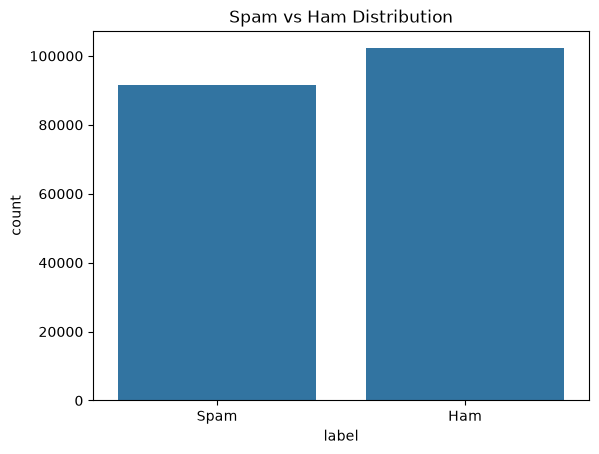

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x='label')
plt.title('Spam vs Ham Distribution')
plt.show()

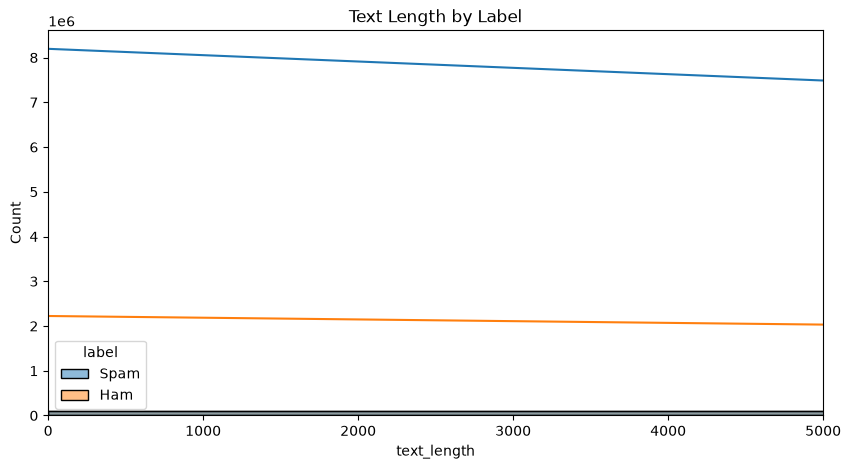

In [6]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='text_length', hue='label', bins=50, kde=True)
plt.xlim(0, 5000)  # zoom in, some emails could be very long outliers
plt.title('Text Length by Label')
plt.show()

In [7]:
df.sort_values('text_length', ascending=False).head(10)[['label', 'text_length']]

,label,text_length
3337,Ham,11510306.0
87933,Ham,605878.0
23254,Ham,605194.0
23725,Ham,598705.0
124756,Ham,274682.0
165369,Ham,228353.0
155778,Ham,225895.0
165569,Ham,214986.0
11090,Ham,191495.0
139493,Ham,186220.0


In [8]:
longest_text = df.sort_values('text_length', ascending=False).iloc[0]['text']
print(longest_text[:500])

bodylabel 0subject great parttime summer job display boxes credit applications need place small owneroperated stores area 1 introduce store owner manager 2 use 90 effective script tells little display box save customers hundreds dollars drawing card business make 5 00 15 00 every app sent 3 find good spot counter place box say nothing need done need name address company send commission checks compensaation 10 every box place becoming representative could also earn commission 10 application came 


In [9]:
print((df['text_length'] > 10000).sum(), "rows over 10,000 chars")
print((df['text_length'] > 50000).sum(), "rows over 50,000 chars")
print((df['text_length'] > 100000).sum(), "rows over 100,000 chars")

3592 rows over 10,000 chars
237 rows over 50,000 chars
58 rows over 100,000 chars


In [10]:
# Drop rows with missing text (the 2 nulls we saw earlier)
df = df.dropna(subset=['text'])

# Truncate extremely long texts to 5000 characters
MAX_LEN = 5000
df['text'] = df['text'].astype(str).str.slice(0, MAX_LEN)

# Recompute text_length to confirm truncation worked
df['text_length'] = df['text'].str.len()
print(df['text_length'].describe())
print(df.shape)

count    193850.000000
mean       1344.071772
std        1389.520378
min           1.000000
25%         362.000000
50%         800.000000
75%        1803.000000
max        5000.000000
Name: text_length, dtype: float64
(193850, 3)


In [11]:
df[['label', 'text']].to_csv('../data/processed_spam_data.csv', index=False)
print("Saved!")

Saved!


In [12]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\supriya\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [13]:
import sys
sys.path.append('../src')

from preprocessing import clean_text

sample = "WIN a FREE iPhone NOW!! Click http://scam-link.com or email us at winner@fakemail.com 🎉🎉"
print(clean_text(sample))

win free iphone click email us 🎉🎉


In [14]:
import pandas as pd
from preprocessing import clean_text_series

df = pd.read_csv('../data/processed_spam_data.csv')

df['clean_text'] = clean_text_series(df['text'])

df.head()

,label,text,clean_text
0,Spam,viiiiiiagraaaa\nonly for the ones that want to...,viiiiiiagraaaa ones want make scream prodigy s...
1,Ham,got ice thought look az original message ice o...,got ice thought look az original message ice o...
2,Spam,yo ur wom an ne eds an escapenumber in ch ma n...,yo ur wom ne eds escapenumber ch n b e th n f ...
3,Spam,start increasing your odds of success & live s...,start increasing odds success live sexually he...
4,Ham,author jra date escapenumber escapenumber esca...,author jra date escapenumber escapenumber esca...


In [15]:
import pandas as pd
import sys
sys.path.append('../src')
from preprocessing import clean_text_series

df = pd.read_csv('../data/processed_spam_data.csv')

df['clean_text'] = clean_text_series(df['text'])

df.head()

,label,text,clean_text
0,Spam,viiiiiiagraaaa\nonly for the ones that want to...,viiiiiiagraaaa ones want make scream prodigy s...
1,Ham,got ice thought look az original message ice o...,got ice thought look az original message ice o...
2,Spam,yo ur wom an ne eds an escapenumber in ch ma n...,yo ur wom ne eds escapenumber ch n b e th n f ...
3,Spam,start increasing your odds of success & live s...,start increasing odds success live sexually he...
4,Ham,author jra date escapenumber escapenumber esca...,author jra date escapenumber escapenumber esca...


In [16]:
empty_after_clean = (df['clean_text'].str.strip() == '').sum()
print(f"{empty_after_clean} rows became empty after cleaning")

38 rows became empty after cleaning


In [17]:
from sklearn.model_selection import train_test_split

df = df[df['clean_text'].str.strip() != '']

X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Train size: 155049
Test size: 38763
label
Ham     0.527027
Spam    0.472973
Name: proportion, dtype: float64
label
Ham     0.527023
Spam    0.472977
Name: proportion, dtype: float64


In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,   # keep only the 5000 most informative words (controls model size/speed)
    ngram_range=(1, 2)   # consider single words AND two-word phrases (e.g. "free money")
)

# Fit ONLY on training data, then transform both train and test
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(X_train_vec.shape)
print(X_test_vec.shape)

(155049, 5000)
(38763, 5000)


In [19]:
import joblib
import os

os.makedirs('../models', exist_ok=True)
joblib.dump(vectorizer, '../models/tfidf_vectorizer.pkl')
print("Vectorizer saved!")

Vectorizer saved!


In [20]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time

models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Linear SVM': LinearSVC()
}

results = []

for name, model in models.items():
    start = time.time()
    model.fit(X_train_vec, y_train)
    train_time = time.time() - start

    y_pred = model.predict(X_test_vec)

    results.append({
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, pos_label='Spam'),
        'recall': recall_score(y_test, y_pred, pos_label='Spam'),
        'f1': f1_score(y_test, y_pred, pos_label='Spam'),
        'train_time_sec': round(train_time, 2)
    })

results_df = pd.DataFrame(results)
print(results_df)

                 model  accuracy  precision    recall        f1  \
0          Naive Bayes  0.941491   0.949072  0.925985  0.937386   
1  Logistic Regression  0.973196   0.967761  0.975837  0.971782   
2           Linear SVM  0.976730   0.971951  0.979055  0.975490   

   train_time_sec  
0            0.63  
1            2.28  
2            5.00  
